# KGAS gNFW Kinematic Fitting

Fit a generalized NFW (gNFW) dark matter velocity profile to KGAS
visibilities using **UVfit** + **KinMS**.  The inner density slope
$\gamma$ is a free MCMC parameter: $\gamma = 0$ is a flat core,
$\gamma = 1$ is a classical NFW cusp.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tempfile
import os

from uvfit import UVDataset, Fitter
from uvfit.forward_model import gnfw_circular_velocity

from empirical_bounds import BoundedGNFWKinMSModel, get_empirical_bounds
from astropy.io import fits as pyfits
from pymakeplots import pymakeplots as pmp

try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False
    print("Install 'corner' for corner plots: pip install corner")

## 2. Configuration

In [8]:
# Galaxy + shared parameters: single source in kgas_config.py (also used by run_kgas_full.py).
from kgas_config import (
    SHARED,
    format_config_log,
    get_galaxy_config,
    vmax_circ_from_obs_band,
)

# from Tim: KGAS7 line 219.999-220.205 GHz; KGAS66 224.148-224.506 GHz.
KGAS_ID = "KGAS066"

_g = get_galaxy_config(KGAS_ID)
DATA_PATH = _g.data_path_default
VSYS = _g.vsys
# gNFW / KinMS peak circular velocity scale from obs band vs vsys (not used for spectral trim).
VMAX = vmax_circ_from_obs_band(_g.obs_freq_range_ghz, VSYS)
R_SCALE = _g.r_scale
PA_INIT = _g.pa_init
INC_INIT = _g.inc_init
OBS_FREQ_RANGE_GHZ = list(_g.obs_freq_range_ghz)

CELLSIZE = SHARED.cellsize_arcsec
F_REST = SHARED.f_rest_hz
C_KMS = SHARED.c_kms
NX = NY = SHARED.nx
VEL_BUFFER = SHARED.vel_buffer_kms

print(format_config_log(KGAS_ID))

SHARED:
  cellsize_arcsec: 0.1
  nx, ny: 256, 256
  vel_buffer_kms: 100.0
  f_rest_hz: 230538000000.0
  c_kms: 299792.458
GALAXY KGAS066:
  kilogas_archive_id: KILOGAS066
  data_path_default: /Users/thbrown/kilogas/DR1/visibilities/KILOGAS066.npz
  vsys: 8066.0
  vmax_circ (from obs_freq_range_ghz vs vsys): 243.58
  r_scale: 7.0
  pa_init: 13.8
  inc_init: 44.0
  obs_freq_range_ghz: [224.148, 224.506]


## 3. Load and inspect data

In [9]:
d = np.load(DATA_PATH)
u_all, v_all = d["u"], d["v"]
vis_all, weights_all = d["vis"], d["weights"]
freqs_all = d["freqs"]

print(f"Baselines : {u_all.shape[0]}")
print(f"Channels  : {freqs_all.shape[0]}")
print(f"Freq range: {freqs_all.min()/1e9:.4f} \u2013 {freqs_all.max()/1e9:.4f} GHz")

Baselines : 43240
Channels  : 1920
Freq range: 223.6669 – 225.5410 GHz


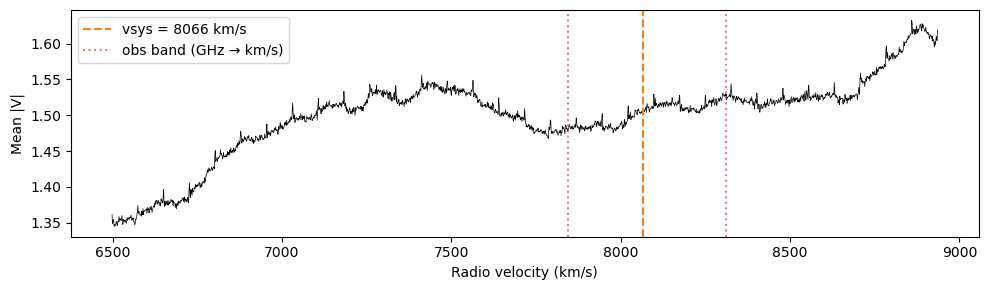

In [10]:
vel_all = C_KMS * (1.0 - freqs_all / F_REST)

avg_amp = np.abs(vis_all).mean(axis=0)

REST_GHZ = F_REST / 1e9
_vlo = C_KMS * (1.0 - max(OBS_FREQ_RANGE_GHZ) / REST_GHZ)
_vhi = C_KMS * (1.0 - min(OBS_FREQ_RANGE_GHZ) / REST_GHZ)

fig, ax1 = plt.subplots(figsize=(10, 3))
ax1.plot(vel_all, avg_amp, "k-", lw=0.5)
ax1.axvline(VSYS, color="C1", ls="--", label=f"vsys = {VSYS:.0f} km/s")
ax1.axvline(_vlo, color="C3", ls=":", alpha=0.6)
ax1.axvline(_vhi, color="C3", ls=":", alpha=0.6,
            label="obs band (GHz → km/s)")
ax1.set_xlabel("Radio velocity (km/s)")
ax1.set_ylabel("Mean |V|")
ax1.legend()
plt.tight_layout()
plt.show()

## 4. Trim to velocity window

In [11]:
# Spectral trim from OBS_FREQ_RANGE_GHZ + VEL_BUFFER (no Vmax / line-width).
obs_freq_hz_lo = min(OBS_FREQ_RANGE_GHZ) * 1e9
obs_freq_hz_hi = max(OBS_FREQ_RANGE_GHZ) * 1e9
_v_at_lo = C_KMS * (1.0 - obs_freq_hz_lo / F_REST)
_v_at_hi = C_KMS * (1.0 - obs_freq_hz_hi / F_REST)
v_lo_band = min(_v_at_lo, _v_at_hi)
v_hi_band = max(_v_at_lo, _v_at_hi)
v_lo = v_lo_band - VEL_BUFFER
v_hi = v_hi_band + VEL_BUFFER

chan_mask = (vel_all >= v_lo) & (vel_all <= v_hi)
freqs_trim = freqs_all[chan_mask]
vis_trim = vis_all[:, chan_mask]
weights_trim = weights_all[:, chan_mask]
vel_trim = vel_all[chan_mask]

dv_kms = float(np.median(np.abs(np.diff(vel_trim))))
n_chan_trim = int(chan_mask.sum())
print(f"Channel width: {dv_kms:.3f} km/s")
print(f"Velocity range: {vel_trim.min():.1f} \u2013 {vel_trim.max():.1f} km/s")
print(f"Trimmed cube will have {n_chan_trim} channels")

uvdata = UVDataset(
    u=u_all, v=v_all,
    vis_data=vis_trim, weights=weights_trim, freqs=freqs_trim,
)

Channel width: 1.270 km/s
Velocity range: 7745.2 – 8409.4 km/s
Trimmed cube will have 524 channels


## 4b. Pre-fit diagnostics

Quick checks on visibility SNR, radial uv-coverage, and physical
resolution before committing to a full MCMC run.

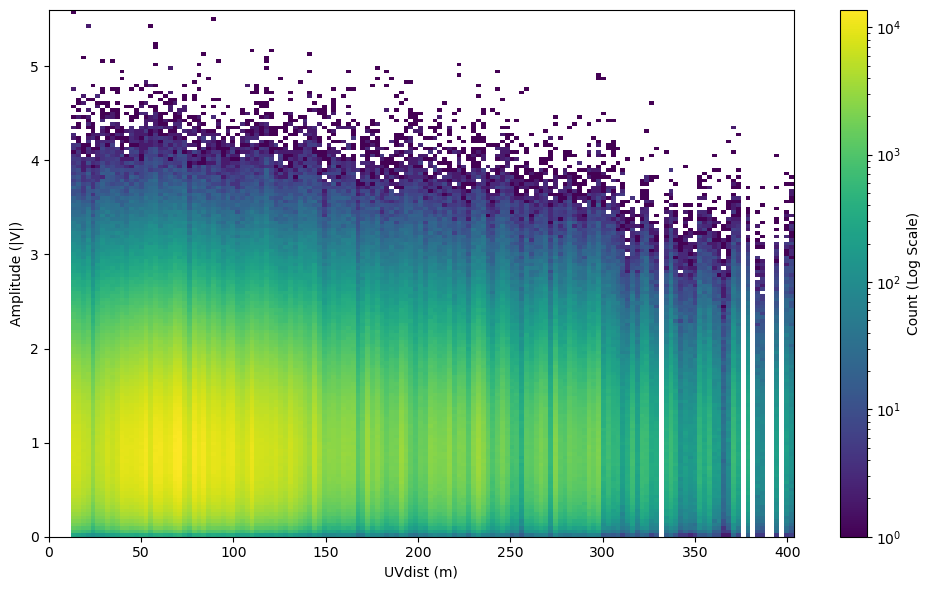

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. Calculate UV distance in wavelengths (q)
q_all = np.sqrt(u_all**2 + v_all**2)

# 2. Convert wavelengths to physical baseline length in meters
C_MS = 299792458.0  # Speed of light in m/s
ref_nu = float(np.median(freqs_all))
lam_m = C_MS / ref_nu
uvdist_m = q_all * lam_m

# 3. Broadcast UV distances to match the 2D visibility array shape
uvdist_m_2d = np.repeat(uvdist_m[:, None], vis_trim.shape[1], axis=1)

# 4. FILTERING: Mask out flagged data and autocorrelations
# This requires your 'weights_trim' array from the earlier pipeline steps
valid_mask = (weights_trim > 0) & (uvdist_m_2d > 0.1)

# Apply the mask (this automatically flattens the arrays, removing the bad points)
amp_valid = np.abs(vis_trim[valid_mask])
uv_valid = uvdist_m_2d[valid_mask]

# 5. Native Matplotlib 2D Histogram
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Pass the cleaned data (uv_valid, amp_valid) to hist2d
counts, xedges, yedges, image = ax.hist2d(
    uv_valid, 
    amp_valid, 
    bins=(150, 150),       
    cmap='viridis',         
    norm=LogNorm()  # Matplotlib handles this natively here
)

# Add the colorbar using the image object returned by hist2d
cb = fig.colorbar(image, ax=ax, label='Count (Log Scale)')

ax.set_xlabel('UVdist (m)')
ax.set_ylabel('Amplitude (|V|)')

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

Masking 367 channels between 7844.0 and 8309.6 km/s


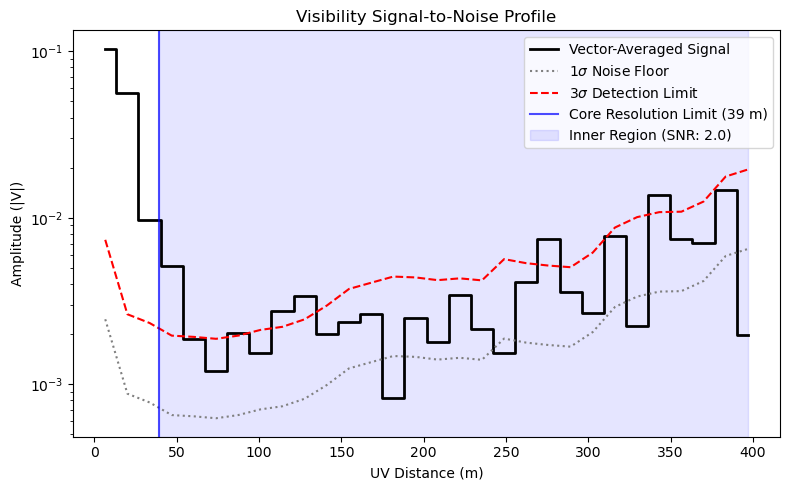

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 0. Convert GHz bounds to km/s to match the trimmed velocity array ---
# Define rest frequency (Assuming CO 2-1, adjust if using a different line)
REST_FREQ_GHZ = 230.53800  
C_KMS = 299792.458         

# High observed frequency = lower velocity (blue-shifted)
v_lo_kms = C_KMS * (1.0 - (max(OBS_FREQ_RANGE_GHZ) / REST_FREQ_GHZ))
v_hi_kms = C_KMS * (1.0 - (min(OBS_FREQ_RANGE_GHZ) / REST_FREQ_GHZ))

# Mask using vel_trim so the boolean array perfectly matches vis_trim (length 367)
line_chan = (vel_trim >= v_lo_kms) & (vel_trim <= v_hi_kms)

print(f"Masking {line_chan.sum()} channels between {v_lo_kms:.1f} and {v_hi_kms:.1f} km/s")

C_MS = 299792458.0  
ref_nu = float(np.median(freqs_all))
lam_m = C_MS / ref_nu

# --- 1. Define Binning Parameters ---
N_BINS = 30
uv_edges = np.linspace(0, float(np.max(uvdist_m)), N_BINS + 1)
uv_centers = 0.5 * (uv_edges[:-1] + uv_edges[1:])

amp_signal = np.zeros(N_BINS)
noise_floor = np.zeros(N_BINS)

# --- 2. Calculate RIGOROUS Weighted Average and Noise per Bin ---
for i in range(N_BINS):
    bin_mask = (uvdist_m >= uv_edges[i]) & (uvdist_m < uv_edges[i+1])
    
    if np.any(bin_mask):
        vis_line = vis_trim[bin_mask][:, line_chan]
        w_line = weights_trim[bin_mask][:, line_chan]
        
        vis_flat = vis_line.flatten()
        w_flat = w_line.flatten()
        
        valid_mask = w_flat > 0
        
        if np.any(valid_mask):
            vis_valid = vis_flat[valid_mask]
            w_valid = w_flat[valid_mask]
            
            # 1. OPTIMIZED SIGNAL: The Weighted Mean
            # Formula: Sum(Vis * Weight) / Sum(Weight)
            weighted_complex_mean = np.sum(vis_valid * w_valid) / np.sum(w_valid)
            amp_signal[i] = np.abs(weighted_complex_mean)
            
            # 2. EXACT NOISE FLOOR: 
            # The theoretical noise of a weighted interferometric mean is 1 / sqrt(Sum(Weights))
            noise_floor[i] = 1.0 / np.sqrt(np.sum(w_valid))

# --- 3. Calculate Critical UV distance and High-q SNR ---
theta_core_rad = R_SCALE * np.pi / (180.0 * 3600.0)
q_crit_m = (1.0 / theta_core_rad) * lam_m

high_q_mask = uv_centers > q_crit_m 
if np.any(high_q_mask) and np.any(noise_floor[high_q_mask] > 0):
    mean_high_q_sig = np.mean(amp_signal[high_q_mask])
    mean_high_q_noise = np.mean(noise_floor[high_q_mask])
    high_q_snr = mean_high_q_sig / mean_high_q_noise
else:
    high_q_snr = 0.0

# --- 4. Plotting ---
fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')

# Plot the vector-averaged signal
ax.step(uv_centers, amp_signal, where='mid', color='black', lw=2, label='Vector-Averaged Signal')

# Plot the 1-sigma and 3-sigma noise floors
ax.plot(uv_centers, noise_floor, color='gray', ls=':', label=r'$1\sigma$ Noise Floor')
ax.plot(uv_centers, 3 * noise_floor, color='red', ls='--', label=r'$3\sigma$ Detection Limit')

# Highlight the region that resolves the Core/Cusp
ax.axvline(q_crit_m, color='blue', ls='-', alpha=0.7, label=f'Core Resolution Limit ({q_crit_m:.0f} m)')
ax.axvspan(q_crit_m, uv_centers[-1], color='blue', alpha=0.1, label=f'Inner Region (SNR: {high_q_snr:.1f})')

# Formatting
ax.set_yscale('log')
# ax.set_xlim(left=0, right=uv_centers[-1])
ax.set_xlabel('UV Distance (m)')
ax.set_ylabel('Amplitude (|V|)')
ax.set_title('Visibility Signal-to-Noise Profile')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 5. gNFW velocity profiles

The generalized NFW density profile has inner slope $\gamma$ as a
continuous parameter:
$$\rho(r) \propto \frac{1}{(r/r_s)^\gamma\,(1 + r/r_s)^{3-\gamma}}$$

$\gamma = 0$ gives a flat core, $\gamma = 1$ gives classical NFW.

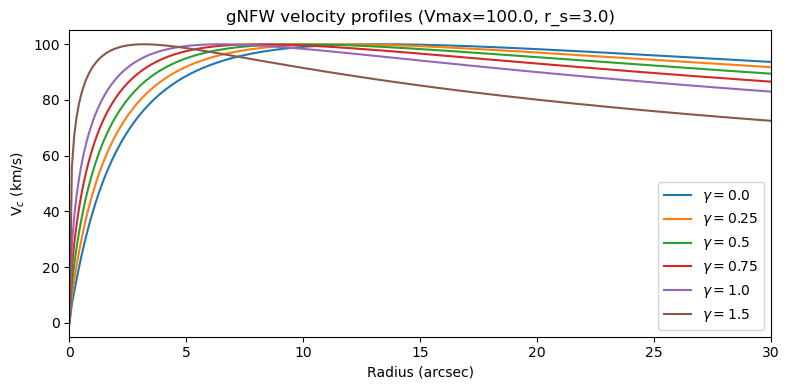

In [21]:
radius = np.arange(0.01, 100, 0.1)
sbprof = np.exp(-radius / R_SCALE)

gammas = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5]
fig, ax = plt.subplots(figsize=(8, 4))
for g in gammas:
    vc = gnfw_circular_velocity(radius, VMAX, R_SCALE, g)
    ax.plot(radius, vc, label=f"$\\gamma={g}$")
ax.set_xlabel("Radius (arcsec)")
ax.set_ylabel("V$_c$ (km/s)")
ax.set_xlim(0, 30)
ax.legend()
ax.set_title(f"gNFW velocity profiles (Vmax={VMAX}, r_s={R_SCALE})")
plt.tight_layout()
plt.show()

## 6. Set up gNFW model and fit

In [22]:
flux_int = _g.flux_int_jy_kms / dv_kms
empirical_bounds = get_empirical_bounds(
    vsys_int=0.0,
    flux_int=flux_int,
    inc_int=INC_INIT,
    pa_int=PA_INIT,
)
print(f"flux_int (catalog Jy·km/s / dv): {flux_int:.6g}")
print(f"Empirical bounds: {empirical_bounds}")

model = BoundedGNFWKinMSModel(
    empirical_bounds=empirical_bounds,
    vmax=VMAX,
    r_scale=R_SCALE,
    radius=radius,
    xs=NX,
    ys=NY,
    vs=n_chan_trim,
    cell_size_arcsec=CELLSIZE,
    channel_width_kms=dv_kms,
    sbprof=sbprof,
    sbrad=radius,
)
fitter = Fitter(uvdata=uvdata, forward_model=model)

init_params = {
    "inc": INC_INIT,
    "pa": PA_INIT,
    "flux": flux_int,
    "vsys": 0.0,
    "gas_sigma": 10.0,
    "gamma": 0.5,
}
print(f"Free parameters: {list(init_params.keys())}")
print(f"Bounds: {model.bounds}")

Free parameters: ['inc', 'pa', 'flux', 'vsys', 'gas_sigma', 'gamma']
Bounds: {'inc': (0.0, 90.0), 'pa': (-180.0, 180.0), 'flux': (0.01, 1000.0), 'vsys': (-500.0, 500.0), 'gas_sigma': (1.0, 200.0), 'gamma': (0.0, 2.0)}


In [23]:
%%time
result_grad = fitter.fit(initial_params=init_params, method="L-BFGS-B")
print(f"L-BFGS-B  rchi2={result_grad.reduced_chi2:.6f}")
print(f"  params: {result_grad.params}")

L-BFGS-B  rchi2=1.103652
  params: {'inc': np.float64(29.0), 'pa': np.float64(147.4), 'flux': np.float64(2.697660620759304), 'vsys': np.float64(0.0), 'gas_sigma': np.float64(10.0), 'gamma': np.float64(0.5)}
CPU times: user 15.2 s, sys: 4.08 s, total: 19.2 s
Wall time: 19.5 s


In [ ]:
%%time
N_WALKERS = 32
N_STEPS = 200
N_BURN = 50

result_mcmc = fitter.fit(
    initial_params=result_grad.params,
    method="emcee",
    n_walkers=N_WALKERS,
    n_steps=N_STEPS,
    n_burn=N_BURN,
)
print(f"emcee MAP  rchi2={result_mcmc.reduced_chi2:.6f}")
print(f"  params: {result_mcmc.params}")

 40%|████      | 81/200 [14:19<20:43, 10.45s/it] 42%|████▏     | 83/200 [14:41<20:28, 10.50s/it] 58%|█████▊    | 117/200 [21:30<17:39, 12.76s/it] 62%|██████▏   | 124/200 [23:04<16:48, 13.27s/it]

## 7. Corner plot

In [ ]:
if HAS_CORNER:
    param_names = list(result_mcmc.params.keys())
    samples = result_mcmc.chains.reshape(-1, len(param_names))
    labels = ["inc", "PA", "flux", r"$v_{\rm sys}$", r"$\sigma_{\rm gas}$", r"$\gamma$"]

    fig = corner.corner(samples, labels=labels, show_titles=True, title_fmt=".3f")
    fig.suptitle("gNFW posterior", y=1.02, fontsize=14)
    plt.show()

## 8. Gamma posterior

In [ ]:
gamma_idx = param_names.index("gamma")
gamma_samples = samples[:, gamma_idx]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gamma_samples, bins=50, density=True, color="C0", alpha=0.7)
ax.axvline(0.0, color="C2", ls="--", lw=2, label=r"$\gamma=0$ (core)")
ax.axvline(1.0, color="C3", ls="--", lw=2, label=r"$\gamma=1$ (NFW cusp)")
med = np.median(gamma_samples)
lo, hi = np.percentile(gamma_samples, [16, 84])
ax.axvline(med, color="k", ls="-", lw=1.5, label=f"median = {med:.2f}")
ax.axvspan(lo, hi, alpha=0.15, color="k", label=f"68% CI = [{lo:.2f}, {hi:.2f}]")
ax.set_xlabel(r"$\gamma$ (inner density slope)")
ax.set_ylabel("Posterior density")
ax.legend()
ax.set_title("Inner slope posterior")
plt.tight_layout()
plt.show()

## 9. Best-fit model cube (pymakeplots)

In [ ]:
def model_cube_to_fits(cube_vyx, vel_kms, cellsize_arcsec, filepath):
    """Write a (v,y,x) numpy model cube to a minimal FITS for pymakeplots."""
    nv, ny, nx = cube_vyx.shape
    dv = float(np.median(np.diff(vel_kms)))
    hdr = pyfits.Header()
    hdr['CTYPE1'] = 'RA---SIN'
    hdr['CTYPE2'] = 'DEC--SIN'
    hdr['CTYPE3'] = 'VRAD'
    hdr['CDELT1'] = -cellsize_arcsec / 3600.0
    hdr['CDELT2'] = cellsize_arcsec / 3600.0
    hdr['CDELT3'] = dv * 1000.0
    hdr['CRPIX1'] = nx / 2.0 + 0.5
    hdr['CRPIX2'] = ny / 2.0 + 0.5
    hdr['CRPIX3'] = 1.0
    hdr['CRVAL1'] = 180.0
    hdr['CRVAL2'] = 45.0
    hdr['CRVAL3'] = float(vel_kms[0]) * 1000.0
    hdr['CUNIT1'] = 'deg'
    hdr['CUNIT2'] = 'deg'
    hdr['CUNIT3'] = 'm/s'
    hdr['BMAJ'] = cellsize_arcsec / 3600.0
    hdr['BMIN'] = cellsize_arcsec / 3600.0
    hdr['BPA'] = 0.0
    hdr['BUNIT'] = 'Jy/beam'
    hdr['RESTFRQ'] = 230538000000.0
    pyfits.writeto(filepath, cube_vyx.astype(np.float32), hdr, overwrite=True)


cube_vyx = model.generate_cube(result_mcmc.params)

tmpfile = tempfile.NamedTemporaryFile(suffix='.fits', delete=False)
model_cube_to_fits(cube_vyx, vel_trim, CELLSIZE, tmpfile.name)
tmpfile.close()
try:
    p = pmp(cube=tmpfile.name)
    p.vsys = VSYS
    p.posang = result_mcmc.params["pa"]
    gamma_map = result_mcmc.params["gamma"]
    p.galname = f"gNFW ($\\gamma$={gamma_map:.2f})"
    p.make_all()
finally:
    os.unlink(tmpfile.name)